In [2]:
%pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 3.5 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from glob import glob
import seaborn as sns

import warnings

In [4]:
warnings.filterwarnings('ignore')

In [9]:
DATASET_PATH = "../data/raw/train"

classes = sorted([
    cls for cls in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, cls))
])

print(f"Number of classes: {len(classes)}")

for cls in classes:
    print(cls)

Number of classes: 38
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___Leaf_scorch
Strawberry___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___he

In [10]:
class_counts = {}

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)
    class_counts[cls] = len(os.listdir(class_path))

df = pd.DataFrame({
    "class": list(class_counts.keys()),
    "count": list(class_counts.values())
})

df = df.sort_values(by="count", ascending=False)

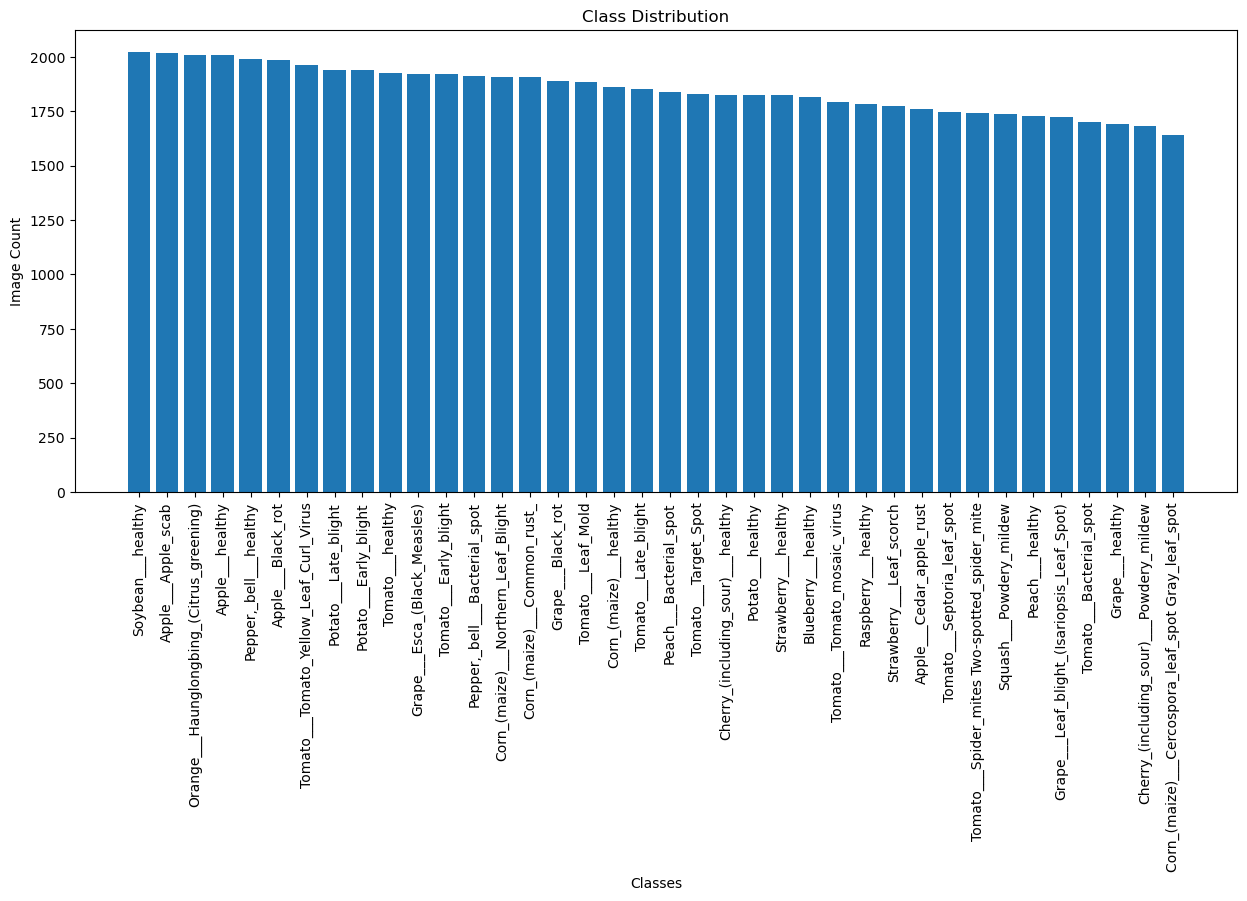

In [11]:
plt.figure(figsize=(15,6))

plt.bar(df["class"], df["count"])

plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Image Count")

plt.show()

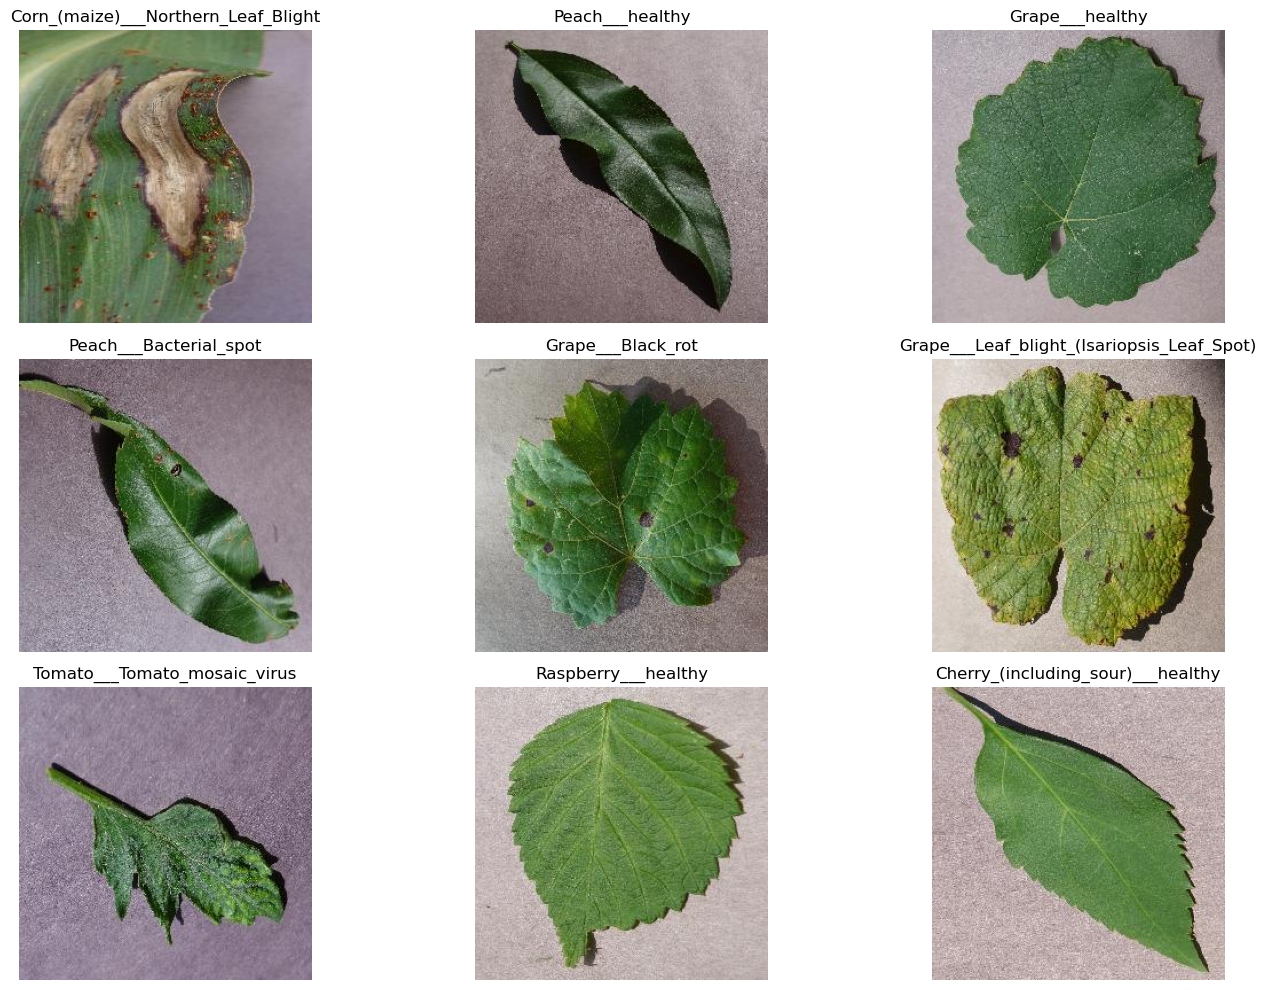

In [25]:
import random

plt.figure(figsize=(15,10))

for i, cls in enumerate(random.sample(classes, 9)):

    image_path = glob(os.path.join(DATASET_PATH, cls, "*.*"))[0]

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
sizes = []

for cls in classes:

    image_paths = glob(os.path.join(DATASET_PATH, cls, "*.jpg"))

    for path in image_paths[:20]:

        image = cv2.imread(path)

        h, w, c = image.shape

        sizes.append((h, w))

sizes[:10]

[(256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256)]

## Resolution Tradeoff

### Higher resolution:

    more detail
    slower inference
    larger memory usage

### Lower resolution:

    faster deployment
    less visual information

becomes a MAJOR edge-AI discussion point later

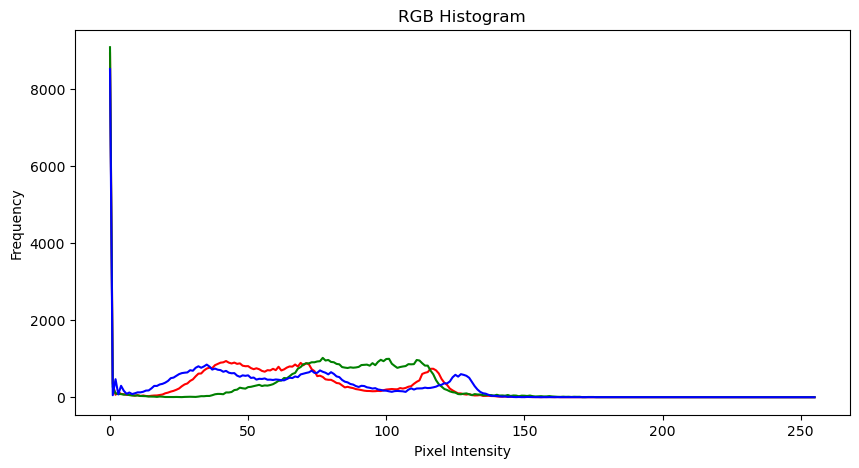

In [29]:
sample_class = classes[0]

sample_image_path = glob(
    os.path.join(DATASET_PATH, sample_class, "*.*")
)[0]

image = cv2.imread(sample_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

colors = ('r', 'g', 'b')

plt.figure(figsize=(10,5))

for i, color in enumerate(colors):

    hist = cv2.calcHist(
        [image],
        [i],
        None,
        [256],
        [0,256]
    )

    plt.plot(hist, color=color)

plt.title("RGB Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

##### Tomato healthy samples dominate several disease categories.
This may bias the CNN toward learning healthy texture priors unless augmentation or balancing strategies are applied.

## 🔥 HEALTHY LEAF INTUITION
Healthy leaves usually have:

    strong green dominance
    smoother texture
    less discoloration

So:
green channel tends to dominate.

Diseased leaves often introduce:
| Disease Effect | Histogram Effect          |
| -------------- | ------------------------- |
| yellowing      | red+green increase        |
| brown spots    | red intensity spikes      |
| dark lesions   | low intensity spikes      |
| mold patches   | texture irregularities    |
| dead tissue    | wider distribution spread |

visual symptom (INTUITION) :

    → color behavior
    → histogram shift
    → ML feature learning


KMeans Segmentation groups pixels by similarity. Usually:
    
    -> color similarity.

Suppose leaf contains:
| Region         | Dominant Color |
| -------------- | -------------- |
| healthy tissue | green          |
| diseased spot  | brown          |
| mold           | yellow         |
| background     | black          |

KMeans may separate these automatically.

KMeans with:
K = 3

might cluster:

    green pixels
    brown pixels
    background pixels

from this CNN focuses on disease regions more clearly. Instead of learning:

    background noise
    irrelevant regions

---

WHY YOUR HISTOGRAM MATTERS

Histogram reveals: ```color separability may exist.```

And if separability exists:

   ##### clustering may work.

---

currently learning:
### feature engineering intuition.
Modern deep learning automates features.

But engineers who understand:

    WHY features matter
    HOW patterns emerge
    WHAT distributions represent

become dramatically stronger practitioners.

# What visual patterns distinguish healthy leaves from diseased leaves?

SIDE-BY-SIDE COMPARISON PANEL 

| Healthy        | Diseased |
| -------------- | -------------- |
| Tomato healthy | Tomato late blight |

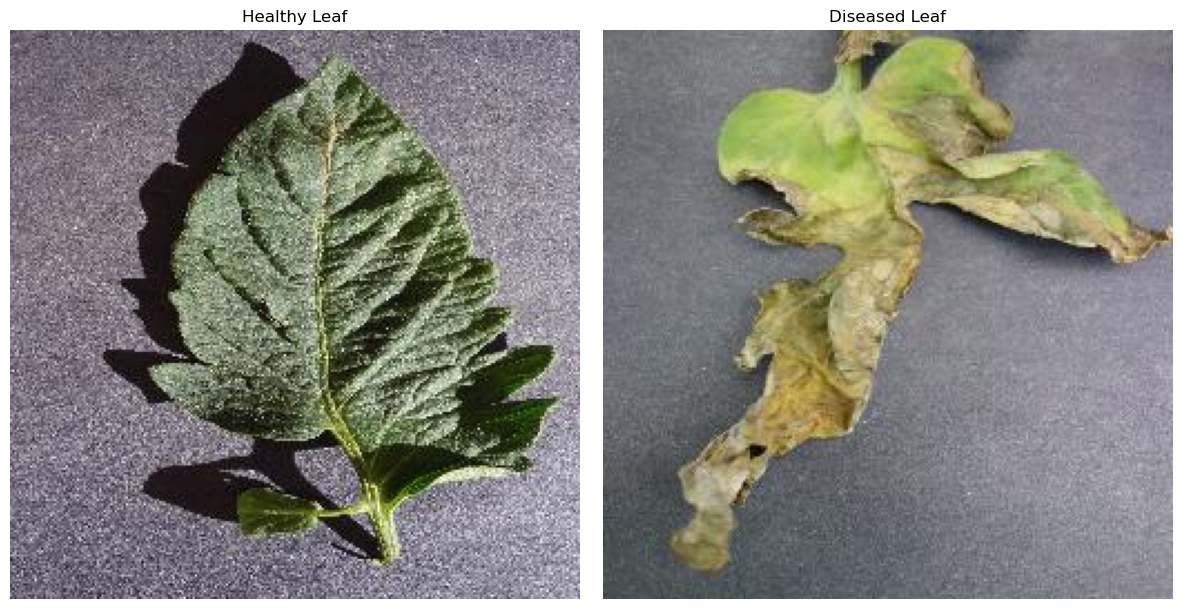

In [34]:
healthy_class = "Tomato___healthy"
diseased_class = "Tomato___Late_blight"

healthy_path = glob(
    os.path.join(DATASET_PATH, healthy_class, "*.*")
)

if len(healthy_path) == 0:
    healthy_path = glob(
        os.path.join(DATASET_PATH, healthy_class, "*.*")
    )

diseased_path = glob(
    os.path.join(DATASET_PATH, diseased_class, "*.*")
)

if len(diseased_path) == 0:
    diseased_path = glob(
        os.path.join(DATASET_PATH, diseased_class, "*.*")
    )

healthy_img = cv2.imread(healthy_path[0])
healthy_img = cv2.cvtColor(healthy_img, cv2.COLOR_BGR2RGB)

diseased_img = cv2.imread(diseased_path[0])
diseased_img = cv2.cvtColor(diseased_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(healthy_img)
plt.title("Healthy Leaf")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(diseased_img)
plt.title("Diseased Leaf")
plt.axis("off")

plt.tight_layout()
plt.show()

| Feature           | Why It Matters                      |
| ----------------- | ----------------------------------- |
| texture           | CNN filters detect texture changes  |
| color             | diseases alter chlorophyll patterns |
| spot distribution | lesions create spatial patterns     |
| shape changes     | structural deformation              |
| edges/boundaries  | infection regions create contrast   |

visual biology
→ image statistics
→ convolution behavior
→ feature learning

This is REAL computer vision thinking.

    HOW TO THINK ABOUT EACH
    1. TEXTURE ANALYSIS
    Healthy Leaf

    Usually:

    smooth
    consistent
    uniform veins
    Diseased Leaf

    May contain:

    rough regions
    lesions
    dry patches
    irregular surfaces
    WHY CNN CARES

    Early convolution filters detect:

    local texture transitions.
    🔥 Named Anchor: Texture Features

    CNNs often classify using:

    micro-patterns
    local texture irregularities

    not:

    “leaf understanding”

    This is extremely important intuition.

    2. COLOR ANALYSIS
    Healthy

    Usually:

    dominant green
    balanced intensity
    Diseased

    May introduce:

    yellow
    brown
    black lesions
    pale regions
    WHY THIS MATTERS

    Disease changes:

    chlorophyll distribution.

    Which changes:

    RGB statistics.

    Which changes:

    convolution activations.
    3. SPOT DISTRIBUTION

    Observe:

    clustered spots?
    scattered spots?
    circular lesions?
    edge concentration?
    WHY IMPORTANT

    CNNs are:

    spatial pattern detectors.

    Not just color detectors.

    Spatial arrangement matters enormously.

    🔥 Named Anchor: Spatial Hierarchy

    CNNs preserve:

    local spatial structure

    This is WHY CNNs outperform simple color histograms.

    4. SHAPE CHANGES

    Observe:

    curling
    deformation
    shriveling
    irregular edges
    WHY IMPORTANT

    Shape deformation creates:

    edge irregularities
    contour changes
    geometry distortions

    which CNN kernels can detect.

    🔥 EXAMPLE OF GOOD OBSERVATION
    ❌ BAD
    Diseased leaf has spots.
    ✅ GOOD
    The diseased leaf exhibits irregular dark lesions and heterogeneous texture patterns compared to the smoother and more color-consistent healthy leaf. These localized high-contrast regions may provide strong activation signals for convolutional filters.

---
## Next,
    🔥 NEXT LEVEL (VERY IMPORTANT)

    After side-by-side visualization:

    CREATE ZOOMED COMPARISONS

    Crop:

    infected spots
    healthy regions

    Then compare micro-texture.

    This becomes:

    incredible presentation material later.
    🔥 OPTIONAL ADVANCED ANALYSIS

    You can later compute:

    Metric	Meaning
    mean RGB	color shifts
    variance	texture complexity
    entropy	visual disorder
    edge density	lesion boundaries
    🔥 Hidden Insight

    Many diseases increase:

    visual entropy.

    Meaning:

    more randomness
    more irregular textures
    more edge discontinuities

    CNNs LOVE learning these signals.

    🔥 WHAT YOU SHOULD WRITE UNDER THIS SECTION

    Example:

    Healthy leaves exhibit relatively uniform green coloration and smoother texture distribution, while diseased leaves contain heterogeneous lesion regions, irregular textures, and localized discoloration. These visual irregularities likely produce distinct convolutional activations, enabling CNNs to learn discriminative disease features.

    That is:

    research-style interpretation